# WithGyro Experiment 0.1 — Paired channel-ablation temporal representation probe

## Research question

How much discriminative information is carried by linear-acceleration events, gyro-derived angular-acceleration events, and their combination across different temporal aggregation scales?

Paired channel sets:

- `accel30`: channels `0:30`;
- `angular30`: channels `30:60`;
- `combined60`: channels `0:60`;
- raw IMU channels `60:66` are excluded.

The primary gyro-contribution contrast is `combined60 - accel30`, computed within each split before aggregation.

## Protocol

- dataset: Angular66 action-0 output at 64 Hz;
- split seeds: `(11, 23, 37, 53, 71)` with 12/4/4 train/validation/test users;
- fixed-duration sweep: `50, 150, 250, 350, 450, 550, 650, 750, 850, 950, 1050 ms`;
- relative-progress sweep: `1, 2, 4, 6, 8, 10, 12, 16, 20` bins;
- feature: channel-wise weighted event count/sum per bin;
- each channel set gets its own train-only z-score standardizer;
- classifiers: multinomial Logistic Regression (`linear`) and 5-NN;
- metrics: Balanced Accuracy, Accuracy, Macro-F1.

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'AGENTS.md').is_file() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
RESULTS_DIR = REPO_ROOT / 'notebooks/artifacts/withGyro/experiment_0_1_temporal_representation_probe/linear_angular_accel_channel_ablation_v3'
RESULTS_PATH = RESULTS_DIR / 'experiment_0_1_results.csv'
SUMMARY_PATH = RESULTS_DIR / 'experiment_0_1_summary.csv'
PAIRED_PATH = RESULTS_DIR / 'experiment_0_1_paired_gains.csv'
PAIRED_SUMMARY_PATH = RESULTS_DIR / 'experiment_0_1_paired_gain_summary.csv'
PROVENANCE_PATH = RESULTS_DIR / 'provenance.json'
for path in (RESULTS_PATH, SUMMARY_PATH, PAIRED_PATH, PAIRED_SUMMARY_PATH, PROVENANCE_PATH):
    if not path.is_file():
        raise FileNotFoundError(f'Missing finalized artifact: {path}\nRun: bash scripts/bash_script/withGyro/submit_exp_0_1_pipeline.bash')
results = pd.read_csv(RESULTS_PATH)
summary = pd.read_csv(SUMMARY_PATH)
paired = pd.read_csv(PAIRED_PATH)
paired_summary = pd.read_csv(PAIRED_SUMMARY_PATH)
provenance = json.loads(PROVENANCE_PATH.read_text(encoding='utf-8'))
print('Results:', RESULTS_PATH)
print('Expected tasks:', provenance['expected_runs'])
print('Result rows:', len(results))

Results: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/withGyro/experiment_0_1_temporal_representation_probe/linear_angular_accel_channel_ablation_v3/experiment_0_1_results.csv
Expected tasks: 100
Result rows: 1200


## 1. Final protocol and provenance

In [2]:
display(pd.Series(provenance, name='value').to_frame())

,value
channel_set_semantics,{'accel30': 'linear-acceleration polarity-spli...
channel_sets,"{'accel30': [0, 30], 'angular30': [30, 60], 'c..."
classifiers,"[linear, 5nn]"
dataset_root,/home/zhaolongwei_umass_edu/projects/writingRi...
event_channel_count,60
event_feature_schema,linear_accel_angular_accel_polarity_split_abs_...
expected_result_rows,1200
expected_runs,100
experiment_id,withGyro_experiment_0_1_temporal_representatio...
feature_schema,linear_accel_angular_accel_polarity_split_wave...


## 2. Aggregate test results

In [3]:
display(summary[[
    'channel_set', 'representation_family', 'condition', 'requested_duration_ms',
    'actual_duration_ms', 'n_bins', 'feature_dim', 'classifier', 'n_splits',
    'mean_test_balanced_accuracy', 'sd_test_balanced_accuracy',
    'mean_test_accuracy', 'mean_test_macro_f1'
]])

,channel_set,representation_family,condition,requested_duration_ms,actual_duration_ms,n_bins,feature_dim,classifier,n_splits,mean_test_balanced_accuracy,sd_test_balanced_accuracy,mean_test_accuracy,mean_test_macro_f1
0,accel30,fixed_duration,fixed_0050ms,50.0,46.875,86,2580,5nn,5,0.123003,0.033036,0.122283,0.070791
1,accel30,fixed_duration,fixed_0150ms,150.0,156.250,26,780,5nn,5,0.282328,0.050331,0.287687,0.272024
2,accel30,fixed_duration,fixed_0250ms,250.0,250.000,16,480,5nn,5,0.351951,0.086232,0.357980,0.342336
3,accel30,fixed_duration,fixed_0350ms,350.0,343.750,12,360,5nn,5,0.374947,0.104083,0.379571,0.373674
4,accel30,fixed_duration,fixed_0450ms,450.0,453.125,9,270,5nn,5,0.384114,0.080701,0.389651,0.372977
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,combined60,relative_progress,relative_08bin,NaN,NaN,8,480,linear,5,0.782381,0.069271,0.783173,0.781625
116,combined60,relative_progress,relative_10bin,NaN,NaN,10,600,linear,5,0.757216,0.092595,0.763118,0.756113
117,combined60,relative_progress,relative_12bin,NaN,NaN,12,720,linear,5,0.737467,0.076735,0.737460,0.739287
118,combined60,relative_progress,relative_16bin,NaN,NaN,16,960,linear,5,0.738373,0.085865,0.739117,0.736211


## 3. Fixed-duration channel-set comparison

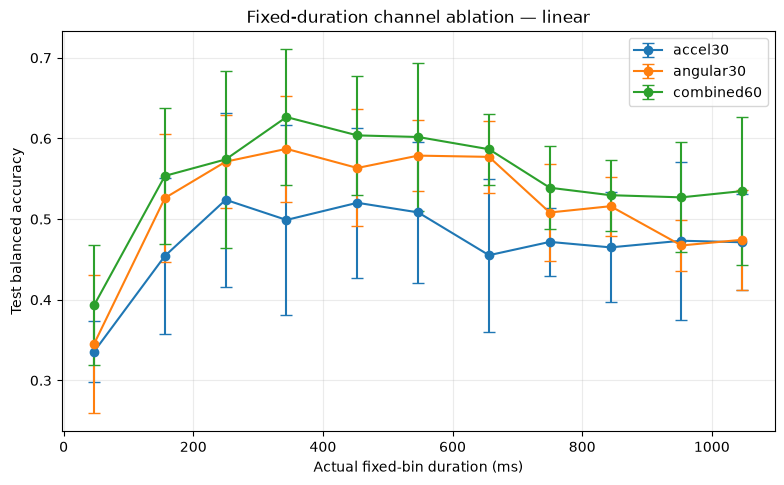

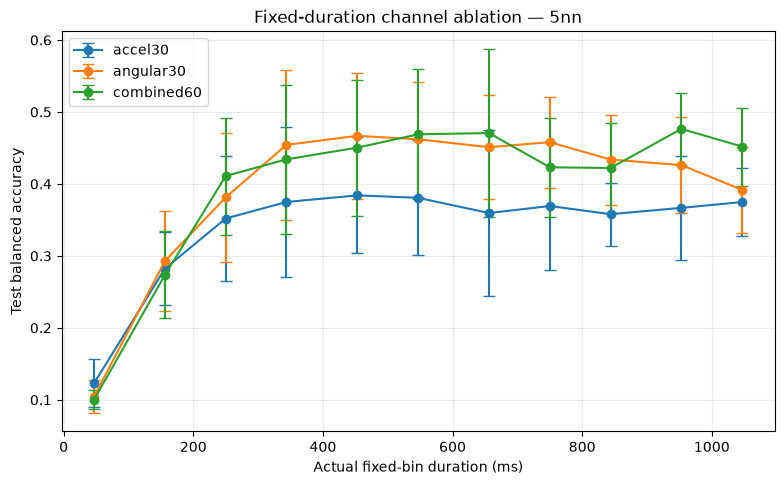

In [4]:
fixed = summary[summary.representation_family == 'fixed_duration'].copy()
for classifier in ('linear', '5nn'):
    fig, ax = plt.subplots(figsize=(9.2, 5.2))
    part = fixed[fixed.classifier == classifier]
    for channel_set, group in part.groupby('channel_set'):
        group = group.sort_values('actual_duration_ms')
        ax.errorbar(group.actual_duration_ms, group.mean_test_balanced_accuracy, yerr=group.sd_test_balanced_accuracy, marker='o', capsize=4, label=channel_set)
    ax.set_xlabel('Actual fixed-bin duration (ms)')
    ax.set_ylabel('Test balanced accuracy')
    ax.set_title(f'Fixed-duration channel ablation — {classifier}')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

## 4. Relative-progress channel-set comparison

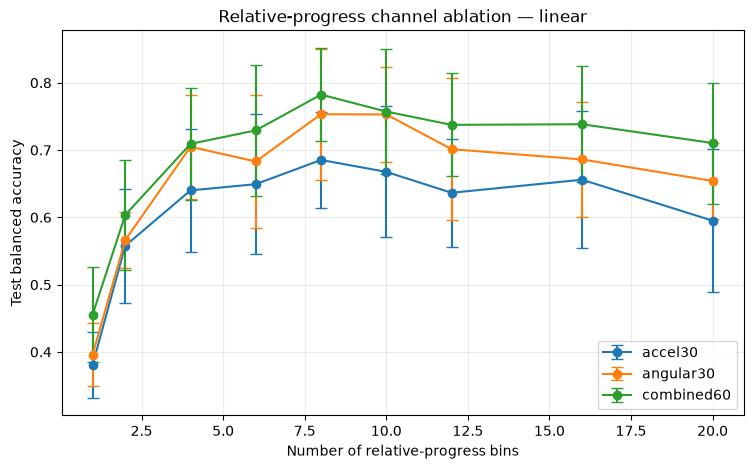

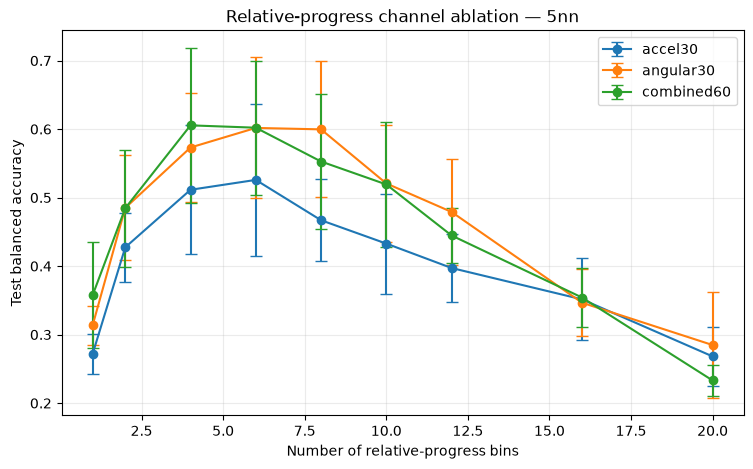

In [5]:
relative = summary[summary.representation_family == 'relative_progress'].copy()
for classifier in ('linear', '5nn'):
    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    part = relative[relative.classifier == classifier]
    for channel_set, group in part.groupby('channel_set'):
        group = group.sort_values('n_bins')
        ax.errorbar(group.n_bins, group.mean_test_balanced_accuracy, yerr=group.sd_test_balanced_accuracy, marker='o', capsize=4, label=channel_set)
    ax.set_xlabel('Number of relative-progress bins')
    ax.set_ylabel('Test balanced accuracy')
    ax.set_title(f'Relative-progress channel ablation — {classifier}')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

## 5. Paired gyro contribution

In [6]:
gain_col = 'mean_delta_balanced_accuracy_combined60_minus_accel30'
gain_sd_col = 'sd_delta_balanced_accuracy_combined60_minus_accel30'
display(paired_summary[[
    'representation_family', 'condition', 'requested_duration_ms', 'actual_duration_ms',
    'n_bins', 'classifier', 'n_splits', gain_col, gain_sd_col
]].sort_values(['classifier', 'representation_family', gain_col], ascending=[True, True, False]))

,representation_family,condition,requested_duration_ms,actual_duration_ms,n_bins,classifier,n_splits,mean_delta_balanced_accuracy_combined60_minus_accel30,sd_delta_balanced_accuracy_combined60_minus_accel30
6,fixed_duration,fixed_0650ms,650.0,656.250,7,5nn,5,0.111138,0.020264
9,fixed_duration,fixed_0950ms,950.0,953.125,5,5nn,5,0.109722,0.031267
5,fixed_duration,fixed_0550ms,550.0,546.875,8,5nn,5,0.088234,0.056347
10,fixed_duration,fixed_1050ms,1050.0,1046.875,4,5nn,5,0.077070,0.035748
4,fixed_duration,fixed_0450ms,450.0,453.125,9,5nn,5,0.066369,0.037669
8,fixed_duration,fixed_0850ms,850.0,843.750,5,5nn,5,0.064140,0.059465
3,fixed_duration,fixed_0350ms,350.0,343.750,12,5nn,5,0.059213,0.071035
2,fixed_duration,fixed_0250ms,250.0,250.000,16,5nn,5,0.059054,0.031112
7,fixed_duration,fixed_0750ms,750.0,750.000,6,5nn,5,0.053862,0.044527
1,fixed_duration,fixed_0150ms,150.0,156.250,26,5nn,5,-0.008763,0.034183


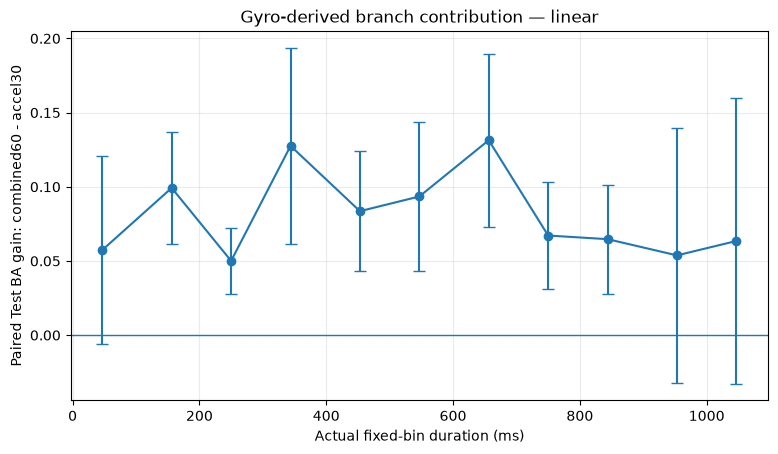

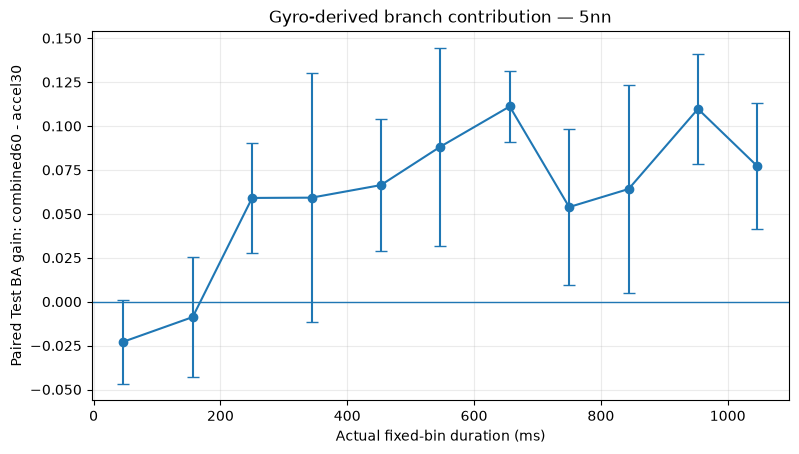

In [7]:
fixed_gain = paired_summary[paired_summary.representation_family == 'fixed_duration'].copy()
for classifier in ('linear', '5nn'):
    group = fixed_gain[fixed_gain.classifier == classifier].sort_values('actual_duration_ms')
    fig, ax = plt.subplots(figsize=(9.0, 4.8))
    ax.errorbar(group.actual_duration_ms, group[gain_col], yerr=group[gain_sd_col], marker='o', capsize=4)
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xlabel('Actual fixed-bin duration (ms)')
    ax.set_ylabel('Paired Test BA gain: combined60 - accel30')
    ax.set_title(f'Gyro-derived branch contribution — {classifier}')
    ax.grid(alpha=0.25)
    plt.show()

## 6. Best conditions per channel set

In [8]:
best = (summary.sort_values('mean_test_balanced_accuracy', ascending=False)
        .groupby(['channel_set', 'representation_family', 'classifier'], as_index=False)
        .head(1)[['channel_set', 'representation_family', 'classifier', 'condition', 'n_bins', 'actual_duration_ms', 'feature_dim', 'mean_test_balanced_accuracy', 'sd_test_balanced_accuracy', 'mean_test_accuracy', 'mean_test_macro_f1']])
display(best)

,channel_set,representation_family,classifier,condition,n_bins,actual_duration_ms,feature_dim,mean_test_balanced_accuracy,sd_test_balanced_accuracy,mean_test_accuracy,mean_test_macro_f1
115,combined60,relative_progress,linear,relative_08bin,8,NaN,480,0.782381,0.069271,0.783173,0.781625
106,angular30,relative_progress,linear,relative_08bin,8,NaN,240,0.753241,0.097363,0.756557,0.750806
97,accel30,relative_progress,linear,relative_08bin,8,NaN,240,0.685298,0.071806,0.685911,0.684772
58,combined60,fixed_duration,linear,fixed_0350ms,12,343.750,720,0.626554,0.084013,0.627625,0.623977
86,combined60,relative_progress,5nn,relative_04bin,4,NaN,240,0.605470,0.112942,0.607884,0.598415
78,angular30,relative_progress,5nn,relative_06bin,6,NaN,180,0.601713,0.102926,0.610448,0.604250
47,angular30,fixed_duration,linear,fixed_0350ms,12,343.750,360,0.587136,0.065330,0.589965,0.580197
69,accel30,relative_progress,5nn,relative_06bin,6,NaN,180,0.525840,0.111156,0.530413,0.519370
35,accel30,fixed_duration,linear,fixed_0250ms,16,250.000,480,0.523975,0.107685,0.525448,0.518474
31,combined60,fixed_duration,5nn,fixed_0950ms,5,953.125,300,0.476481,0.050041,0.483115,0.453373


## Interpretation

Use `accel30` vs `angular30` to compare the standalone discriminative content of the two event branches. Use `combined60 - accel30` as the primary measure of incremental information contributed by the gyro-derived angular-acceleration branch. Because `combined60` has twice the channel count of either 30-channel branch, a positive gain supports complementary information in the added branch, not greater information efficiency per channel. Linear is the main linearly-accessible-information probe; 5-NN is a secondary local-geometry probe.